In [1]:
import matplotlib.pyplot as plt
import distinctipy
import numpy as np 
import pandas as pd 
import os 
import pickle
import matplotlib
import sys
from pathlib import Path
REPO_ROOT = Path.cwd().resolve().parents[2]
sys.path.insert(0, str(REPO_ROOT / "code"))
import plot_of_experiment_data
from make_network import sez
matplotlib.rcParams['svg.fonttype'] = 'none'
matplotlib.rcParams['font.family'] = 'Arial'
matplotlib.rcParams['font.size'] = 7

In [2]:

fpath = 'data/optogenetics_geosmin_pathway_251119.xlsx'
sheets = pd.ExcelFile(fpath)
sheets = sheets.sheet_names
df_all = {}
for s in sheets:
    df = pd.read_excel(fpath,sheet_name=s)
    df_all[s] = df 
    


['Or56a',
 'LH1990',
 'LH1989',
 'meteor SS35420',
 'meteor SS35412',
 'hortail SS51950',
 'hortail SS41428',
 'web SS41446',
 'web SS41448',
 'web SS41434']

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

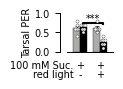

In [5]:
stat_per_sheets = {}
num_data_per_sheets = {}
for s in ['web SS41434']:#sheets:
    df = df_all[s]

    fig, ax = plt.subplots(1, 1, figsize=(0.6, 0.5))
    data,pivot,error = plot_of_experiment_data.make_pivot_optogenetics_data(df)
    ax,stat_all = plot_of_experiment_data.draw_paired_bar_figure(
        data=data,
        mean_df=pivot,
        err_df=error,
        ax=ax,
        bar_width = .1,
        bar_spacing = .3,
        dot_size = 5,
        linewidth=.25,
        capsize=1.5,
        conds=[0, 1],
        stat_fontsize=7,
        fontsize=7,
        groups=['retinal (-)', 'retinal (+)'],
        get_values=lambda data, cond, group: data[(cond, 0 if group == 'retinal (-)' else 1)],
        stat_pairs=[
            ((0, 'retinal (+)'), (1, 'retinal (+)'))
        ],
        colors=('#AEACAB', 'black'),
        ylabel='Tarsal PER',
        xtick_func=lambda c: '-' if c == 0 else '+',
        ylim=(0, 0.8),
        yticks=np.round(np.arange(0, 1.2, .5), 2)
    )
    ax.set_xlim(-0.2, 0.5)
    ax.set_ylim(0, 1)
    sucrose = ['+', '+']
    light = ['-', '+']

    ax.set_xticks([])

    y_offset = -0.15
    bar_width = 0.1
    bar_spacing = 0.3
    x_loc = np.arange(0, 2 * bar_spacing, bar_spacing)

    ax.text(-0.1, y_offset*1.5, '100 mM Suc.',
            fontsize=7, ha='right', va='top')
    ax.text(-0.1, y_offset * 3, 'red light',
            fontsize=7, ha='right', va='top')

    for i, x in enumerate(x_loc):
        ax.text(x, y_offset*1.5, sucrose[i],
                fontsize=7, ha='center', va='top')
        ax.text(x, y_offset * 3, light[i],
                fontsize=7, ha='center', va='top')
    ax.spines['left'].set_position(('outward', 5))
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)

    ax.legend().remove()
    stat_per_sheets[s] = stat_all
    ax.tick_params(
    axis='both',
    width=.7,      # tick line 두께
    )
    for spine in ax.spines.values():
        spine.set_linewidth(.7)
    num_data_per_sheets[s] = {x:len(y) for x,y in data.items()}
    plt.savefig(f'figures/{s}.svg')
    

In [14]:
stat_per_sheets

{'Or56a': [(48.0, 0.0013554633420686869)],
 'LH1990': [(24.5, 0.007198989393205724)],
 'LH1989': [(34.5, 0.004305063308653183)],
 'meteor SS35420': [(15.5, 0.2950069435816731)],
 'meteor SS35412': [(38.5, 0.2537968584323281)],
 'hortail SS51950': [(64.0, 0.0004223084513626899)],
 'hortail SS41428': [(64.0, 0.0003890667343176733)],
 'web SS41446': [(25.0, 0.004733677195156858)],
 'web SS41448': [(63.0, 0.00053073066078509)]}

In [15]:
num_data_per_sheets

{'Or56a': {(0, 0): 6, (0, 1): 7, (1, 0): 6, (1, 1): 7},
 'LH1990': {(0, 0): 5, (0, 1): 5, (1, 0): 5, (1, 1): 5},
 'LH1989': {(0, 0): 6, (0, 1): 6, (1, 0): 6, (1, 1): 6},
 'meteor SS35420': {(0, 0): 4, (0, 1): 5, (1, 0): 4, (1, 1): 5},
 'meteor SS35412': {(0, 0): 8, (0, 1): 8, (1, 0): 8, (1, 1): 8},
 'hortail SS51950': {(0, 0): 8, (0, 1): 8, (1, 0): 8, (1, 1): 8},
 'hortail SS41428': {(0, 0): 8, (0, 1): 8, (1, 0): 8, (1, 1): 8},
 'web SS41446': {(0, 0): 4, (0, 1): 5, (1, 0): 4, (1, 1): 5},
 'web SS41448': {(0, 0): 7, (0, 1): 8, (1, 0): 7, (1, 1): 8}}

In [6]:
stat_per_sheets

{'web SS41434': [(49.0, 0.0008981624427972955)]}

In [7]:
num_data_per_sheets

{'web SS41434': {(0, 0): 6, (0, 1): 7, (1, 0): 6, (1, 1): 7}}